## YOLOv8 | Half Precision Comparison

**NOTE** This notebook should only be used to display the results. Running it may result in some errors. The effect of HalfPrecision is provided at the bottom of the notebook.

Half Precision (FP16) is a numerical format used in YOLO and other deep learning models. This format represents floating-point numbers with lower precision (16-bit), which results in reduced memory usage. It provides performance improvements and more efficient memory usage, especially during computations with GPU acceleration.


**YOLO and Half Precision:**

Deep learning models like YOLO can perform faster and more efficiently by using half precision (FP16), especially for GPU-based acceleration.

Models like YOLOv5 and YOLOv6 benefit from half precision, particularly on platforms like CUDA and TensorRT, which results in speed improvements.

**Benefits:**

* **Faster training and testing:** The model runs faster because computations are done with fewer bits.
* **Lower memory consumption:** Less memory is used, which is particularly useful for large models and datasets.
* **More efficient GPU usage:** Tensor Cores (special hardware units in NVIDIA GPUs) are optimized for FP16 operations.

**Summary:**

Half Precision (FP16) is a technique used to enhance the performance of models like YOLO. It provides speed and efficiency, though some loss of accuracy may occur. However, in tasks like image processing and object detection, where accuracy loss is often not critical, FP16 is commonly used.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
%cd /content/drive/MyDrive/YOLOv8 Model Optimization/03_Half Precision

/content/drive/MyDrive/YOLOv8 Model Optimization/03_Half Precision


In [4]:
%pip install ultralytics

import ultralytics
ultralytics.checks()

Ultralytics YOLOv8.1.40 🚀 Python-3.10.12 torch-2.2.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 28.9/78.2 GB disk)


# mAP for Half Precision Comparison

**Results have been obtained using two different values (True/False) for Half Precision on the same model (yolov8l.pt).**


In [ ]:
# The half-precision value is set to half=false below.

In [5]:
!yolo detect val model=yolov8l.pt data=coco128.yaml iou=0.5 half=False name=yolov8l_test_half_false

100% 83.7M/83.7M [00:00<00:00, 188MB/s]
Ultralytics YOLOv8.1.40 🚀 Python-3.10.12 torch-2.2.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
YOLOv8l summary (fused): 268 layers, 43668288 parameters, 0 gradients, 165.2 GFLOPs

Dataset 'coco128.yaml' images not found ⚠️, missing path '/content/drive/MyDrive/YOLOv8 Model Optimization/03_Half Precision/datasets/coco128/images/train2017'
100% 6.66M/6.66M [00:00<00:00, 127MB/s]
Unzipping /content/drive/MyDrive/YOLOv8 Model Optimization/03_Half Precision/datasets/coco128.zip to /content/drive/MyDrive/YOLOv8 Model Optimization/03_Half Precision/datasets/coco128...: 100% 263/263 [00:01<00:00, 137.22file/s]
Dataset download success ✅ (4.7s), saved to /content/drive/MyDrive/YOLOv8 Model Optimization/03_Half Precision/datasets

100% 755k/755k [00:00<00:00, 115MB/s]
val: Scanning /content/drive/MyDrive/YOLOv8 Model Optimization/03_Half Precision/datasets/coco128/labels/train2017... 126 images, 2 backgrounds, 0 corrupt: 100% 128/128 [00:01<00:00, 97.61it/s] 
val:

In [6]:
!yolo detect val model=yolov8l.pt data=coco128.yaml iou=0.5 half=True name=yolov8l_test_half_true

Ultralytics YOLOv8.1.40 🚀 Python-3.10.12 torch-2.2.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
YOLOv8l summary (fused): 268 layers, 43668288 parameters, 0 gradients, 165.2 GFLOPs
val: Scanning /content/drive/MyDrive/YOLOv8 Model Optimization/03_Half Precision/datasets/coco128/labels/train2017.cache... 126 images, 2 backgrounds, 0 corrupt: 100% 128/128 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% 8/8 [00:09<00:00,  1.16s/it]
                   all        128        929      0.711      0.787      0.829       0.65
                person        128        254      0.821      0.779      0.863      0.669
               bicycle        128          6      0.814      0.667       0.74      0.518
                   car        128         46      0.858      0.522      0.651      0.347
            motorcycle        128          5      0.777          1      0.962      0.822
              airplane        128          6      0.892          1  

# FPS for Half Precision Comparison

In [7]:
from helper import process_video

YOLOv8l - Half Precision: False

In [8]:
video_path = "./inference/test.mp4"
save_path = "./results/test_half_false_result.mp4"

model_path = "./yolov8l.pt"

image_size = 320
half_precision = False

process_video(video_path, model_path, save_path, image_size, half_precision)

[INFO]: Video is processing..
[INFO]: Processing task is completed successfully!..
Result video is saved in: ./results/test_half_false_result.mp4


YOLOv8l - Half Precision: True

In [9]:
video_path = "./inference/test.mp4"
save_path = "./results/test_half_true_result.mp4"

model_path = "./yolov8l.pt"

image_size = 320
half_precision = True

process_video(video_path, model_path, save_path, image_size, half_precision)

[INFO]: Video is processing..
[INFO]: Processing task is completed successfully!..
Result video is saved in: ./results/test_half_true_result.mp4


**Resulting Table**

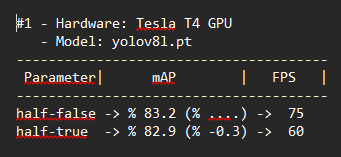  

**COMMENT:**
The mAP values are the same for both. In some cases, it might have been observed that True gave better results, but since the mAP is the same in both, the decision should be based on FPS. Since the model with half=False is faster in FPS, it would be better to choose it here.